In [1]:
# Import packages and set configurations
# *** do not try to open things without "head"***

import polars as pl
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Counts vs local SHAP for RBFOX2 bound at pos 4 for K562

In [2]:
# File path to massive data
# Read in data

K562_PATH = "/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/6_SHAP_network_analysis/outputs/FINAL_AVERAGE_SHAP_CACHE/K562_all-data.feather"
K562 = pl.read_ipc(K562_PATH)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [3]:
# Filter for K562, get rows where RBP_KD_Target = RBFOX2, has_RBP_KD_4 = true

filtered_K562 = (
    K562
    .filter(
        (pl.col("RBP_KD_Target") == "RBFOX2") & (pl.col("has_RBP_KD_4"))
    )
)

filtered_K562.head(5)

index,AARS_1_binding,AATF_1_binding,ABCF1_1_binding,ADAT1_1_binding,AGGF1_1_binding,AKAP1_1_binding,AKAP8L_1_binding,APEX1_1_binding,APOBEC3C_1_binding,AQR_1_binding,BUD13_1_binding,CPEB4_1_binding,CPSF6_1_binding,CSTF2T_1_binding,DDX1_1_binding,DDX21_1_binding,DDX24_1_binding,DDX3X_1_binding,DDX42_1_binding,DDX43_1_binding,DDX47_1_binding,DDX51_1_binding,DDX52_1_binding,DDX55_1_binding,DDX6_1_binding,DGCR8_1_binding,DHX30_1_binding,DROSHA_1_binding,EEF2_1_binding,EFTUD2_1_binding,EIF3G_1_binding,EIF4E_1_binding,EIF4G2_1_binding,ELAC2_1_binding,ELAVL1_1_binding,EWSR1_1_binding,EXOSC10_1_binding,EXOSC5_1_binding,FAM120A_1_binding,FASTKD2_1_binding,FMR1_1_binding,FTO_1_binding,FUS_1_binding,FXR1_1_binding,FXR2_1_binding,GARS_1_binding,GEMIN5_1_binding,GNL3_1_binding,GPKOW_1_binding,GRWD1_1_binding,GTF2F1_1_binding,HLTF_1_binding,HNRNPA1_1_binding,HNRNPC_1_binding,HNRNPK_1_binding,HNRNPL_1_binding,HNRNPM_1_binding,HNRNPU_1_binding,HNRNPUL1_1_binding,IGF2BP1_1_binding,IGF2BP2_1_binding,ILF3_1_binding,KHDRBS1_1_binding,KHSRP_1_binding,LARP4_1_binding,LARP7_1_binding,LIN28B_1_binding,LSM11_1_binding,MATR3_1_binding,MBNL1_1_binding,METAP2_1_binding,METTL1_1_binding,MORC2_1_binding,MTPAP_1_binding,NCBP2_1_binding,NIPBL_1_binding,NOLC1_1_binding,NONO_1_binding,NPM1_1_binding,NSUN2_1_binding,PABPC4_1_binding,PCBP1_1_binding,PHF6_1_binding,PPIL4_1_binding,PRPF8_1_binding,PTBP1_1_binding,PUM1_1_binding,PUM2_1_binding,PUS1_1_binding,QKI_1_binding,RBFOX2_1_binding,RBM15_1_binding,RBM22_1_binding,RNF187_1_binding,RPS10_1_binding,RPS11_1_binding,RPS3_1_binding,RPS6_1_binding,RYBP_1_binding,SAFB_1_binding,SAFB2_1_binding,SBDS_1_binding,SDAD1_1_binding,SERBP1_1_binding,SF3B1_1_binding,SF3B4_1_binding,SLBP_1_binding,SLTM_1_binding,SMNDC1_1_binding,SND1_1_binding,SRSF1_1_binding,SRSF7_1_binding,SRSF9_1_binding,SSB_1_binding,SUPV3L1_1_binding,TAF15_1_binding,TARDBP_1_binding,TBRG4_1_binding,TIA1_1_binding,TRA2A_1_binding,TROVE2_1_binding,U2AF1_1_binding,U2AF2_1_binding,UCHL5_1_binding,UPF1_1_binding,UTP18_1_binding,UTP3_1_binding,WDR3_1_binding,WDR43_1_binding,WRN_1_binding,XRCC6_1_binding,XRN2_1_binding,YBX3_1_binding,YWHAG_1_binding,ZC3H11A_1_binding,ZC3H8_1_binding,ZNF622_1_binding,ZNF800_1_binding,ZRANB2_1_binding,AARS_2_binding,AATF_2_binding,ABCF1_2_binding,ADAT1_2_binding,AGGF1_2_binding,AKAP1_2_binding,AKAP8L_2_binding,APEX1_2_binding,APOBEC3C_2_binding,AQR_2_binding,BUD13_2_binding,CPEB4_2_binding,CPSF6_2_binding,CSTF2T_2_binding,DDX1_2_binding,DDX21_2_binding,DDX24_2_binding,DDX3X_2_binding,DDX42_2_binding,DDX43_2_binding,DDX47_2_binding,DDX51_2_binding,DDX52_2_binding,DDX55_2_binding,DDX6_2_binding,DGCR8_2_binding,DHX30_2_binding,DROSHA_2_binding,EEF2_2_binding,EFTUD2_2_binding,EIF3G_2_binding,EIF4E_2_binding,EIF4G2_2_binding,ELAC2_2_binding,ELAVL1_2_binding,EWSR1_2_binding,EXOSC10_2_binding,EXOSC5_2_binding,FAM120A_2_binding,FASTKD2_2_binding,FMR1_2_binding,FTO_2_binding,FUS_2_binding,FXR1_2_binding,FXR2_2_binding,GARS_2_binding,GEMIN5_2_binding,GNL3_2_binding,GPKOW_2_binding,GRWD1_2_binding,GTF2F1_2_binding,HLTF_2_binding,HNRNPA1_2_binding,HNRNPC_2_binding,HNRNPK_2_binding,HNRNPL_2_binding,HNRNPM_2_binding,HNRNPU_2_binding,HNRNPUL1_2_binding,IGF2BP1_2_binding,IGF2BP2_2_binding,ILF3_2_binding,KHDRBS1_2_binding,KHSRP_2_binding,LARP4_2_binding,LARP7_2_binding,LIN28B_2_binding,LSM11_2_binding,MATR3_2_binding,MBNL1_2_binding,METAP2_2_binding,METTL1_2_binding,MORC2_2_binding,MTPAP_2_binding,NCBP2_2_binding,NIPBL_2_binding,NOLC1_2_binding,NONO_2_binding,NPM1_2_binding,NSUN2_2_binding,PABPC4_2_binding,PCBP1_2_binding,PHF6_2_binding,PPIL4_2_binding,PRPF8_2_binding,PTBP1_2_binding,PUM1_2_binding,PUM2_2_binding,PUS1_2_binding,QKI_2_binding,RBFOX2_2_binding,RBM15_2_binding,RBM22_2_binding,RNF187_2_binding,RPS10_2_binding,RPS11_2_binding,RPS3_2_binding,RPS6_2_binding,RYBP_2_binding,SAFB_2_binding,SAFB2_2_binding,SBDS_2_binding,SDAD1_2_binding,SERBP1_2_binding,SF3B1_2_binding,SF3B4_2_binding,SLBP_2_binding,SLTM_2_binding,SMNDC1_2_binding,SND1_2_bin

In [4]:
# Get rid of unneccessary columns 

columns_to_keep = [
    "RBP_KD_Target",
    "Sample Name",
    "FDR",
    "has_RBP_KD_4",
    "Raw P-Val",
    "RBFOX2_4_shap",
    "RBFOX2_4_binding"
]

filtered_K562 = filtered_K562.select(columns_to_keep)

In [ ]:
print(filtered_K562)

In [5]:
# Make another dataframe that has all rows where RBFOX2 is bound at pos 4 including the in-silico KDs

rbfox2_bound_4_K562 = (
    K562
    .filter(
        (pl.col("RBFOX2_4_binding") == 1)
        | (
            (pl.col("has_RBP_KD_4"))
            & (pl.col("RBP_KD_Target") == "RBFOX2")
        )
    )
)

rbfox2_bound_4_K562 = rbfox2_bound_4_K562.select(columns_to_keep)

In [11]:
print(rbfox2_bound_4_K562)
type(rbfox2_bound_4_K562)

polars.dataframe.frame.DataFrame

In [6]:
# convert to pandas
df_pd = rbfox2_bound_4_K562.to_pandas()
df_pd.head()

,RBP_KD_Target,Sample Name,FDR,has_RBP_KD_4,Raw P-Val,RBFOX2_4_shap,RBFOX2_4_binding
0,CPEB4,CPEB4_KD-1,0.904775,False,0.111217,-0.053446,1
1,PUM2,PUM2_KD-1,1.000000,False,0.799656,-0.053446,1
2,AARS,AARS_KD-1,1.000000,False,1.000000,-0.029920,1
3,AARS,AARS_KD-2,1.000000,False,1.000000,-0.029920,1
4,ABCF1,ABCF1_KD-1,1.000000,False,1.000000,-0.029920,1


In [7]:
# Confirm that shap at pos 4 is never positive

df_sorted = df_pd.sort_values(by="RBFOX2_4_shap", ascending=False)

print(df_sorted.head(10))

      RBP_KD_Target  Sample Name       FDR  has_RBP_KD_4  Raw P-Val  \
9164         RBFOX2  RBFOX2_KD-2  1.000000          True   1.000000   
8302         RBFOX2  RBFOX2_KD-2  1.000000          True   1.000000   
6136         RBFOX2  RBFOX2_KD-1  1.000000          True   0.141223   
5971         RBFOX2  RBFOX2_KD-1  0.003717          True   0.000013   
13730        RBFOX2  RBFOX2_KD-1  1.000000          True   0.685309   
13731        RBFOX2  RBFOX2_KD-2  1.000000          True   0.685309   
5674         RBFOX2  RBFOX2_KD-2  1.000000          True   0.597725   
5673         RBFOX2  RBFOX2_KD-1  1.000000          True   0.597725   
5566         RBFOX2  RBFOX2_KD-2  0.920560          True   0.116743   
5565         RBFOX2  RBFOX2_KD-1  0.920560          True   0.116743   

       RBFOX2_4_shap  RBFOX2_4_binding  
9164             0.0                 0  
8302             0.0                 0  
6136             0.0                 0  
5971             0.0                 0  
13730        

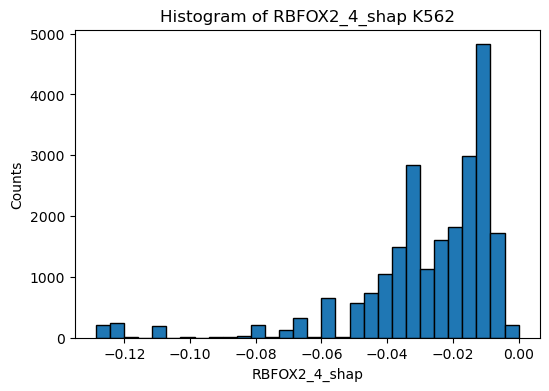

In [8]:
# make histogram
plt.figure(figsize=(6,4))
plt.hist(df_pd["RBFOX2_4_shap"], bins=30, edgecolor="black")
plt.xlabel("RBFOX2_4_shap")
plt.ylabel("Counts")
plt.title("Histogram of RBFOX2_4_shap K562")
plt.show()

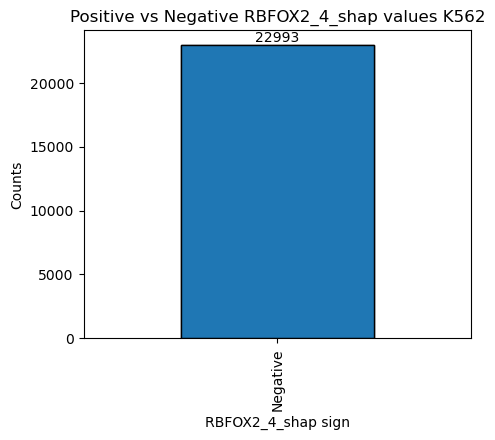

In [9]:
df_pd["shap_sign"] = df_pd["RBFOX2_4_shap"].apply(lambda x: "Positive" if x > 0 else "Negative")

# count how many in each category
counts = df_pd["shap_sign"].value_counts()

# plot
plt.figure(figsize=(5,4))
counts.plot(kind="bar", edgecolor="black")
ax = counts.plot(kind="bar", edgecolor="black")
plt.xlabel("RBFOX2_4_shap sign")
plt.ylabel("Counts")
plt.title("Positive vs Negative RBFOX2_4_shap values K562")
for i, count in enumerate(counts):
    ax.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)
plt.show()

# Counts vs local SHAP for RBFOX2 bound at pos 4 for HepG2

In [3]:
# File paths to massive data

HEPG2_PATH = "/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/6_SHAP_network_analysis/outputs/FINAL_AVERAGE_SHAP_CACHE/HepG2_all-data.feather"
HEPG2 = pl.read_ipc(HEPG2_PATH)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [5]:
# Filter for HEPG2, get rows where RBP_KD_Target = RBFOX2, has_RBP_KD_4 = true

filtered_HEPG2 = (
    HEPG2
    .filter(
        (pl.col("RBP_KD_Target") == "RBFOX2") & (pl.col("has_RBP_KD_4"))
    )
)

filtered_HEPG2.head(5)

index,AGGF1_1_binding,AKAP1_1_binding,AQR_1_binding,BCCIP_1_binding,BCLAF1_1_binding,BUD13_1_binding,CDC40_1_binding,CSTF2_1_binding,CSTF2T_1_binding,DDX3X_1_binding,DDX52_1_binding,DDX55_1_binding,DDX59_1_binding,DDX6_1_binding,DGCR8_1_binding,DHX30_1_binding,DKC1_1_binding,DROSHA_1_binding,EFTUD2_1_binding,EIF3D_1_binding,EIF3H_1_binding,EXOSC5_1_binding,FAM120A_1_binding,FASTKD2_1_binding,FKBP4_1_binding,FTO_1_binding,FUBP3_1_binding,FUS_1_binding,FXR2_1_binding,G3BP1_1_binding,GRSF1_1_binding,GRWD1_1_binding,GTF2F1_1_binding,HLTF_1_binding,HNRNPA1_1_binding,HNRNPC_1_binding,HNRNPK_1_binding,HNRNPL_1_binding,HNRNPM_1_binding,HNRNPU_1_binding,HNRNPUL1_1_binding,IGF2BP1_1_binding,IGF2BP3_1_binding,ILF3_1_binding,KHSRP_1_binding,LARP4_1_binding,LARP7_1_binding,LIN28B_1_binding,LSM11_1_binding,MATR3_1_binding,NCBP2_1_binding,NIP7_1_binding,NKRF_1_binding,NOL12_1_binding,NOLC1_1_binding,NSUN2_1_binding,PABPN1_1_binding,PCBP1_1_binding,PCBP2_1_binding,POLR2G_1_binding,PPIG_1_binding,PRPF4_1_binding,PRPF8_1_binding,PTBP1_1_binding,QKI_1_binding,RBFOX2_1_binding,RBM15_1_binding,RBM22_1_binding,RBM5_1_binding,RPS3_1_binding,SAFB_1_binding,SDAD1_1_binding,SF3A3_1_binding,SF3B4_1_binding,SFPQ_1_binding,SLTM_1_binding,SMNDC1_1_binding,SND1_1_binding,SRSF1_1_binding,SRSF7_1_binding,SRSF9_1_binding,SSB_1_binding,STAU2_1_binding,SUB1_1_binding,SUGP2_1_binding,SUPV3L1_1_binding,TAF15_1_binding,TARDBP_1_binding,TBRG4_1_binding,TIA1_1_binding,TIAL1_1_binding,TRA2A_1_binding,TROVE2_1_binding,U2AF1_1_binding,U2AF2_1_binding,UCHL5_1_binding,UPF1_1_binding,UTP18_1_binding,WDR43_1_binding,XPO5_1_binding,XRCC6_1_binding,XRN2_1_binding,YBX3_1_binding,ZC3H11A_1_binding,ZNF800_1_binding,AGGF1_2_binding,AKAP1_2_binding,AQR_2_binding,BCCIP_2_binding,BCLAF1_2_binding,BUD13_2_binding,CDC40_2_binding,CSTF2_2_binding,CSTF2T_2_binding,DDX3X_2_binding,DDX52_2_binding,DDX55_2_binding,DDX59_2_binding,DDX6_2_binding,DGCR8_2_binding,DHX30_2_binding,DKC1_2_binding,DROSHA_2_binding,EFTUD2_2_binding,EIF3D_2_binding,EIF3H_2_binding,EXOSC5_2_binding,FAM120A_2_binding,FASTKD2_2_binding,FKBP4_2_binding,FTO_2_binding,FUBP3_2_binding,FUS_2_binding,FXR2_2_binding,G3BP1_2_binding,GRSF1_2_binding,GRWD1_2_binding,GTF2F1_2_binding,HLTF_2_binding,HNRNPA1_2_binding,HNRNPC_2_binding,HNRNPK_2_binding,HNRNPL_2_binding,HNRNPM_2_binding,HNRNPU_2_binding,HNRNPUL1_2_binding,IGF2BP1_2_binding,IGF2BP3_2_binding,ILF3_2_binding,KHSRP_2_binding,LARP4_2_binding,LARP7_2_binding,LIN28B_2_binding,LSM11_2_binding,MATR3_2_binding,NCBP2_2_binding,NIP7_2_binding,NKRF_2_binding,NOL12_2_binding,NOLC1_2_binding,NSUN2_2_binding,PABPN1_2_binding,PCBP1_2_binding,PCBP2_2_binding,POLR2G_2_binding,PPIG_2_binding,PRPF4_2_binding,PRPF8_2_binding,PTBP1_2_binding,QKI_2_binding,RBFOX2_2_binding,RBM15_2_binding,RBM22_2_binding,RBM5_2_binding,RPS3_2_binding,SAFB_2_binding,SDAD1_2_binding,SF3A3_2_binding,SF3B4_2_binding,SFPQ_2_binding,SLTM_2_binding,SMNDC1_2_binding,SND1_2_binding,SRSF1_2_binding,SRSF7_2_binding,SRSF9_2_binding,SSB_2_binding,STAU2_2_binding,SUB1_2_binding,SUGP2_2_binding,SUPV3L1_2_binding,TAF15_2_binding,TARDBP_2_binding,TBRG4_2_binding,TIA1_2_binding,TIAL1_2_binding,TRA2A_2_binding,TROVE2_2_binding,U2AF1_2_binding,U2AF2_2_binding,UCHL5_2_binding,UPF1_2_binding,UTP18_2_binding,WDR43_2_binding,XPO5_2_binding,XRCC6_2_binding,XRN2_2_binding,YBX3_2_binding,ZC3H11A_2_binding,ZNF800_2_binding,AGGF1_3_binding,AKAP1_3_binding,AQR_3_binding,BCCIP_3_binding,BCLAF1_3_binding,BUD13_3_binding,CDC40_3_binding,CSTF2_3_binding,CSTF2T_3_binding,DDX3X_3_binding,DDX52_3_binding,DDX55_3_binding,DDX59_3_binding,DDX6_3_binding,DGCR8_3_binding,DHX30_3_binding,DKC1_3_binding,DROSHA_3_binding,EFTUD2_3_binding,EIF3D_3_binding,EIF3H_3_binding,EXOSC5_3_binding,FAM120A_3_binding,FASTKD2_3_binding,FKBP4_3_binding,FTO_3_binding,FUBP3_3_binding,FUS_3_binding,FXR2_3_binding,G3BP1_3_binding,GRSF1_3_binding,GRWD1_3_binding,GTF2F1_3_binding,HLTF_3_binding,HNRNPA1_3_binding,HNRNPC_3_binding,HNRNPK_3_binding,HNRNPL_3_binding,HNRNPM_3_

In [6]:
filtered_HEPG2 = filtered_HEPG2.select(columns_to_keep)

In [8]:
rbfox2_bound_4_HEPG2 = (
    HEPG2
    .filter(
        (pl.col("RBFOX2_4_binding") == 1)
        | (
            (pl.col("has_RBP_KD_4"))
            & (pl.col("RBP_KD_Target") == "RBFOX2")
        )
    )
)

rbfox2_bound_4_HEPG2 = rbfox2_bound_4_HEPG2.select(columns_to_keep)

In [10]:
df2_pd = rbfox2_bound_4_HEPG2.to_pandas()
df2_pd.head()

,RBP_KD_Target,Sample Name,FDR,has_RBP_KD_4,Raw P-Val,RBFOX2_4_shap,RBFOX2_4_binding
0,AKAP1,AKAP1_KD-1,0.022312,False,0.000912,-0.076067,1
1,AKAP1,AKAP1_KD-2,0.022312,False,0.000912,-0.076067,1
2,AQR,AQR_KD-1,0.996622,False,0.202299,-0.078049,1
3,AQR,AQR_KD-2,0.996622,False,0.202299,-0.078049,1
4,BCCIP,BCCIP_KD-1,1.000000,False,0.866445,-0.076067,1


In [11]:
# Checking shap manually

df2_sorted = df2_pd.sort_values(by="RBFOX2_4_shap", ascending=False)

print(df2_sorted.head(10))

      RBP_KD_Target  Sample Name      FDR  has_RBP_KD_4  Raw P-Val  \
37998        RBFOX2  RBFOX2_KD-2  1.00000          True   0.633039   
17989        RBFOX2  RBFOX2_KD-2  1.00000          True   1.000000   
17988        RBFOX2  RBFOX2_KD-1  1.00000          True   1.000000   
49356        RBFOX2  RBFOX2_KD-1  0.08170          True   0.006068   
49357        RBFOX2  RBFOX2_KD-2  0.08170          True   0.006068   
21770        RBFOX2  RBFOX2_KD-2  0.17607          True   0.019566   
21769        RBFOX2  RBFOX2_KD-1  0.17607          True   0.019566   
15743        RBFOX2  RBFOX2_KD-2  1.00000          True   0.388622   
15742        RBFOX2  RBFOX2_KD-1  1.00000          True   0.388622   
414          RBFOX2  RBFOX2_KD-2  1.00000          True   1.000000   

       RBFOX2_4_shap  RBFOX2_4_binding  
37998       0.001950                 0  
17989       0.001920                 0  
17988       0.001920                 0  
49356       0.001900                 0  
49357       0.001900    

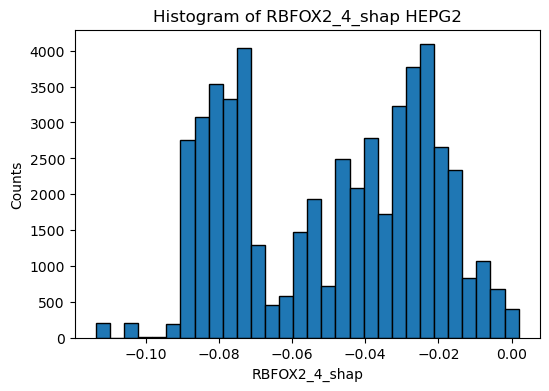

In [18]:
# make histogram
plt.figure(figsize=(6,4))
plt.hist(df2_pd["RBFOX2_4_shap"], bins=30, edgecolor="black")
plt.xlabel("RBFOX2_4_shap")
plt.ylabel("Counts")
plt.title("Histogram of RBFOX2_4_shap HEPG2")
plt.show()

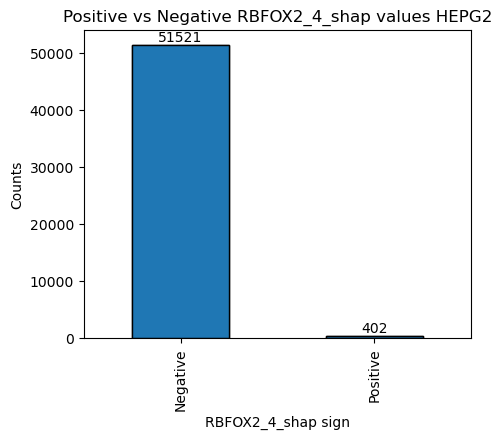

In [17]:
df2_pd["shap_sign"] = df2_pd["RBFOX2_4_shap"].apply(lambda x: "Positive" if x > 0 else "Negative")

# count how many in each category
counts = df2_pd["shap_sign"].value_counts()

# plot
plt.figure(figsize=(5,4))
counts.plot(kind="bar", edgecolor="black")
ax = counts.plot(kind="bar", edgecolor="black")
plt.xlabel("RBFOX2_4_shap sign")
plt.ylabel("Counts")
plt.title("Positive vs Negative RBFOX2_4_shap values HEPG2")
for i, count in enumerate(counts):
    ax.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)
plt.show()

In [14]:
print(counts)

shap_sign
Negative    51521
Positive      402
Name: count, dtype: int64
